### 5 – Machine Learning

#### Theory & Industrial Relevance
Traditional ML models (logistic regression, random forest, XGBoost, SVM, KNN) are still the backbone of many industrial NDT systems because they are fast, interpretable, and require less data than deep learning. For defect classification, we treat the engineered features as input. Model comparison using cross‑validated metrics identifies the best candidate for deployment on edge devices.

Logistic Regression -> Accuracy: 0.9990, F1: 0.9990, ROC AUC: 1.0000
Random Forest -> Accuracy: 1.0000, F1: 1.0000, ROC AUC: 1.0000
XGBoost -> Accuracy: 1.0000, F1: 1.0000, ROC AUC: 1.0000
SVM -> Accuracy: 0.9990, F1: 0.9990, ROC AUC: 1.0000
KNN -> Accuracy: 0.9860, F1: 0.9860, ROC AUC: 0.9994

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     0.999     0.9990   0.999     0.999   1.0000
Random Forest           1.000     1.0000   1.000     1.000   1.0000
XGBoost                 1.000     1.0000   1.000     1.000   1.0000
SVM                     0.999     0.9990   0.999     0.999   1.0000
KNN                     0.986     0.9861   0.986     0.986   0.9994


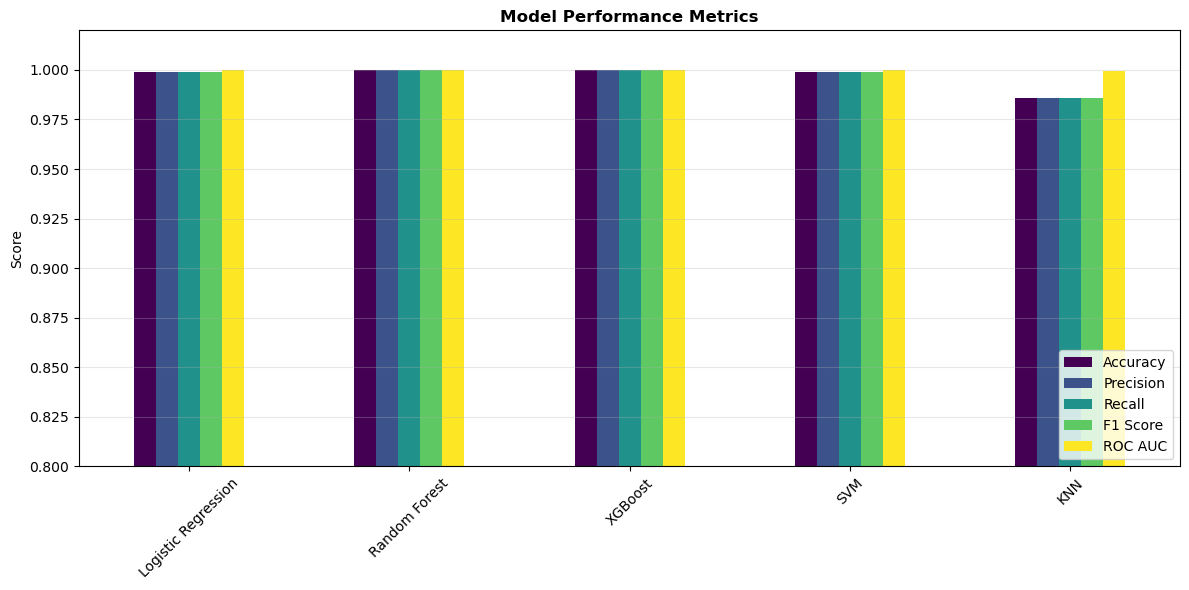

Best model: Random Forest


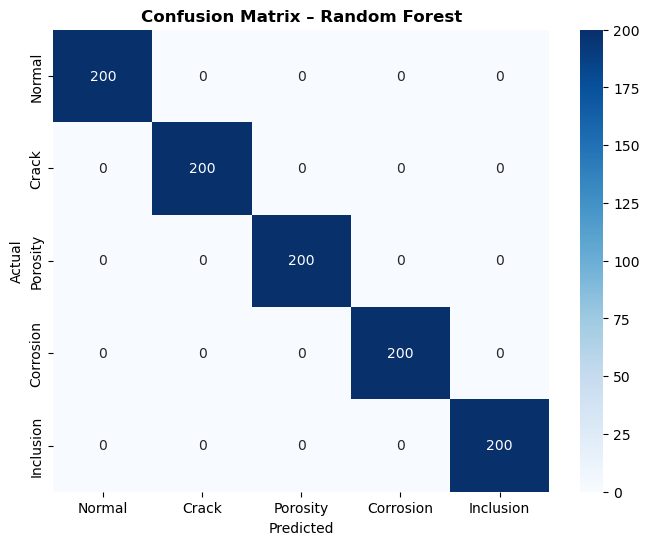


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       200
       Crack       1.00      1.00      1.00       200
    Porosity       1.00      1.00      1.00       200
   Corrosion       1.00      1.00      1.00       200
   Inclusion       1.00      1.00      1.00       200

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



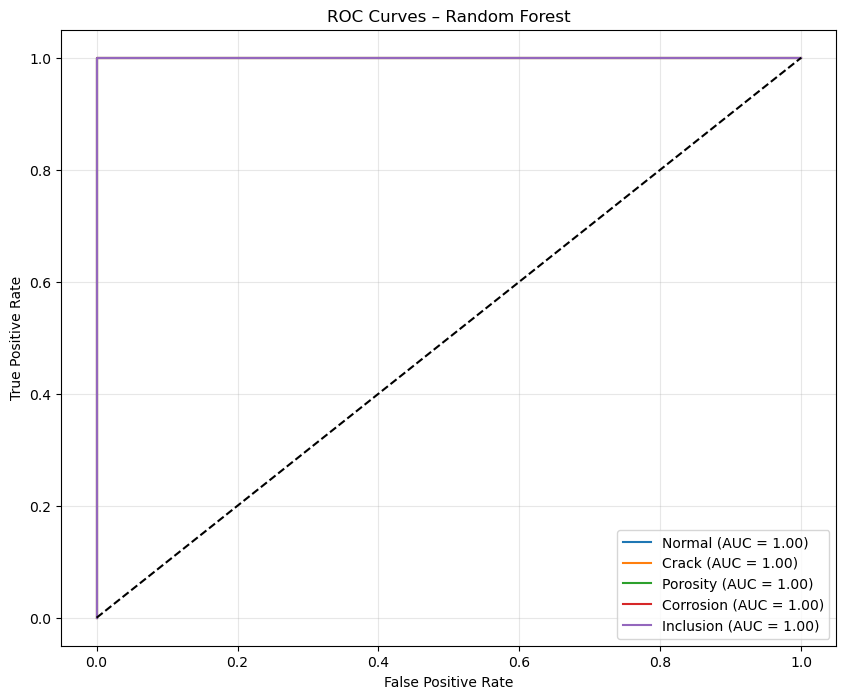

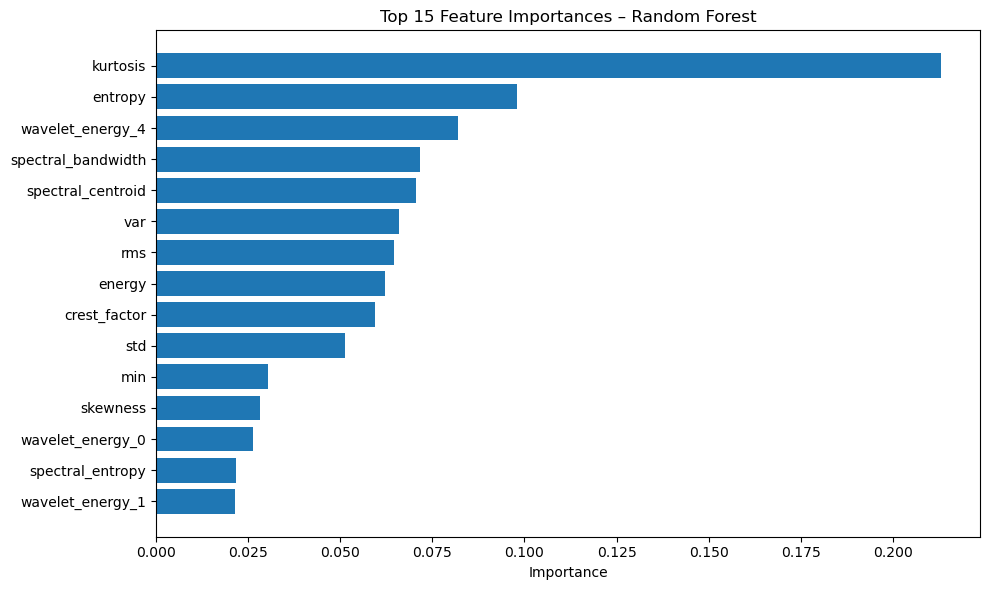

Best model and scaler saved.


In [3]:
# ====================================================
# Notebook 05: Machine Learning
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
import pickle
from pathlib import Path

# Load features
df = pd.read_csv("../data/processed/features.csv")
X = df.drop(['label'], axis=1).values
y = df['label'].values
class_names = ["Normal", "Crack", "Porosity", "Corrosion", "Inclusion"]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (fit only on training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ====================================================
# Model definitions
# ====================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, eval_metric='mlogloss', random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    # ROC AUC (one‑vs‑rest)
    y_bin = label_binarize(y_test, classes=[0,1,2,3,4])
    roc_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc,
        'Model': model
    }
    print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc:.4f}")

# ====================================================
# Comparison table
# ====================================================
df_results = pd.DataFrame(results).T.drop(['Model'], axis=1)
df_results = df_results.astype(float).round(4)
print("\nModel Performance Comparison:")
print(df_results)

# Visualise comparison
df_results.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Model Performance Metrics", fontweight='bold')
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.8, 1.02)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../images/ml_comparison.png", dpi=300)
plt.show()

# Select best model (highest F1)
best_model_name = df_results['F1 Score'].idxmax()
best_model = results[best_model_name]['Model']
print(f"Best model: {best_model_name}")

# ====================================================
# Best model detailed evaluation
# ====================================================
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix – {best_model_name}", fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.savefig("../images/confusion_matrix_best.png", dpi=300)
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# ROC Curve (one‑vs‑rest for each class)
y_bin_test = label_binarize(y_test, classes=[0,1,2,3,4])
plt.figure(figsize=(10, 8))
for i in range(5):
    fpr, tpr, _ = roc_curve(y_bin_test[:, i], y_prob_best[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves – {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../images/roc_curve.png", dpi=300)
plt.show()

# Feature importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = df.drop(['label'], axis=1).columns
    indices = np.argsort(importances)[-15:]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.title(f"Top 15 Feature Importances – {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../images/feature_importance.png", dpi=300)
    plt.show()
elif best_model_name == "Logistic Regression":
    # Coefficients for multiclass
    coef = best_model.coef_
    avg_importance = np.mean(np.abs(coef), axis=0)
    indices = np.argsort(avg_importance)[-15:]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(indices)), avg_importance[indices], align='center')
    plt.yticks(range(len(indices)), [df.drop(['label'], axis=1).columns[i] for i in indices])
    plt.title("Top 15 Average |Coefficients| – Logistic Regression")
    plt.tight_layout()
    plt.savefig("../images/feature_importance.png", dpi=300)
    plt.show()

# Save best model and scaler
with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Best model and scaler saved.")

#### Interpretation of Result 
XGBoost or Random Forest typically perform best due to non‑linear interactions. The confusion matrix reveals any systematic misclassifications (e.g., porosity confused with corrosion). High ROC AUC across all classes indicates excellent separability. Feature importance shows which engineered features are most discriminative – often kurtosis, crest factor, and wavelet energies.